# 2026 FIFA World Cup — Bayesian Group Stage Predictions

**Approach:** Gelman-style hierarchical Bayesian model fitted to 2022 World Cup results and
2026 qualifying matches (qualified-team pairs only). FIFA rankings used as the prior.
Score differences modelled as Student-t(ν=7). Win/draw/loss classified with a ±0.5 goal threshold.

---

In [1]:
# --- Environment setup (must run before the Stan model is compiled) ---
# This machine's Homebrew Python was built against an SDK path that no longer
# exists (.../MacOSX12.sdk), so the C++ linker fails with "library 'c++' not found".
# Point the compiler/linker at the current SDK so httpstan can build the model.
import os, sys, subprocess

if sys.platform == "darwin":
    try:
        sdk = subprocess.check_output(["xcrun", "--show-sdk-path"], text=True).strip()
        if sdk and os.path.isdir(sdk):
            os.environ["SDKROOT"]      = sdk
            os.environ["CFLAGS"]       = f"-isysroot {sdk}"
            os.environ["CPPFLAGS"]     = f"-isysroot {sdk}"
            os.environ["LDFLAGS"]      = f"-isysroot {sdk}"
            os.environ["LDSHARED"]     = f"clang -bundle -undefined dynamic_lookup -isysroot {sdk}"
            os.environ["LDCXXSHARED"]  = f"clang++ -bundle -undefined dynamic_lookup -isysroot {sdk}"
            print(f"SDK configured: {sdk}")
        else:
            print("xcrun returned no valid SDK path; leaving compiler env untouched.")
    except Exception as e:
        print(f"Could not query SDK via xcrun ({e}); leaving compiler env untouched.")

SDK configured: /Applications/Xcode.app/Contents/Developer/Platforms/MacOSX.platform/Developer/SDKs/MacOSX.sdk


## 0. Setup

In [2]:
import nest_asyncio
nest_asyncio.apply()  # PyStan 3 calls asyncio.run() internally; allow it inside the kernel's event loop

import stan
import numpy as np
import pandas as pd
import json
import urllib.request, io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import t as t_dist
import warnings
warnings.filterwarnings('ignore')

BLUE, RED, GRAY, GOLD, DARK, BG = '#1d6fa4','#c0392b','#7f8c8d','#e67e22','#2c3e50','#f8f9fa'
DRAW_THRESHOLD = 0.5
print("Libraries loaded.")

/Users/robineast/Documents/world_cup_2026/.venv/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Libraries loaded.


## 1. Qualified teams & group assignments

In [3]:
groups = {
    'A': ["Mexico","South Africa","South Korea","Czech Republic"],
    'B': ["Canada","Bosnia and Herzegovina","Qatar","Switzerland"],
    'C': ["Brazil","Morocco","Haiti","Scotland"],
    'D': ["United States","Paraguay","Australia","Turkey"],
    'E': ["Germany","Curaçao","Ivory Coast","Ecuador"],
    'F': ["Netherlands","Japan","Sweden","Tunisia"],
    'G': ["Belgium","Egypt","Iran","New Zealand"],
    'H': ["Spain","Cape Verde","Saudi Arabia","Uruguay"],
    'I': ["France","Senegal","Iraq","Norway"],
    'J': ["Argentina","Algeria","Austria","Jordan"],
    'K': ["Portugal","DR Congo","Uzbekistan","Colombia"],
    'L': ["England","Croatia","Ghana","Panama"],
}
# "Curaçao" matches the source dataset spelling (martj42/international_results)
qualified  = {t for ts in groups.values() for t in ts}
team_group = {t: g for g, ts in groups.items() for t in ts}
print(f"Total qualified teams: {len(qualified)}")

Total qualified teams: 48


## 2. FIFA Rankings (April 2025)

In [4]:
rankings = {
    "Argentina":1,"Spain":2,"France":3,"England":4,"Brazil":5,
    "Belgium":6,"Netherlands":7,"Portugal":8,"Colombia":9,"Germany":12,
    "Croatia":13,"Uruguay":14,"Mexico":15,"United States":16,"Morocco":17,
    "Japan":18,"Senegal":19,"Iran":20,"Switzerland":21,"Ecuador":23,
    "Australia":24,"South Korea":25,"Canada":26,"Turkey":27,"Austria":28,
    "Czech Republic":29,"Norway":31,"Egypt":32,"Algeria":34,"Sweden":35,
    "Paraguay":37,"Tunisia":38,"Scotland":39,"Iraq":40,"South Africa":41,
    "Jordan":42,"Saudi Arabia":43,"Ghana":44,"Bosnia and Herzegovina":45,
    "Panama":46,"Qatar":47,"Ivory Coast":48,"DR Congo":51,
    "Uzbekistan":58,"Cape Verde":62,"Curaçao":82,"New Zealand":95,"Haiti":100,
}
teams       = sorted(rankings.keys())
team_idx    = {t: i+1 for i, t in enumerate(teams)}
ranks       = np.array([rankings[t] for t in teams], dtype=float)
inv_ranks   = ranks.max() - ranks + 1
prior_score = (inv_ranks - inv_ranks.mean()) / (2 * inv_ranks.std(ddof=1))
print(f"Prior score range: {prior_score.min():.3f} to {prior_score.max():.3f}")

Prior score range: -1.535 to 0.663


## 3. Training data

In [5]:
url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
req = urllib.request.Request(url, headers={"User-Agent":"WC2026Bot/1.0"})
with urllib.request.urlopen(req) as resp:
    df_all = pd.read_csv(io.BytesIO(resp.read()))

# Team names now match the dataset's spelling (incl. "Curaçao") directly
qualified_ds = qualified

wc22 = df_all[
    (df_all['tournament']=='FIFA World Cup') &
    (df_all['date']>='2022-11-01') & (df_all['date']<'2023-01-01') &
    (df_all['home_team'].isin(qualified_ds)) & (df_all['away_team'].isin(qualified_ds))
][['date','home_team','away_team','home_score','away_score']].copy()
wc22['source'] = 'wc2022'

qual26 = df_all[
    (df_all['tournament']=='FIFA World Cup qualification') &
    (df_all['date']>'2022-12-18') &
    (df_all['home_team'].isin(qualified_ds)) & (df_all['away_team'].isin(qualified_ds)) &
    (~df_all['home_score'].isna())
][['date','home_team','away_team','home_score','away_score']].copy()
qual26['source'] = 'qual2026'

matches = pd.concat([wc22, qual26], ignore_index=True)
print(f"2022 WC games:      {len(wc22)}")
print(f"2026 qualifying:    {len(qual26)}")
print(f"Total training:     {len(matches)}")

2022 WC games:      46
2026 qualifying:    64
Total training:     110


### Figure 4 — Training data coverage

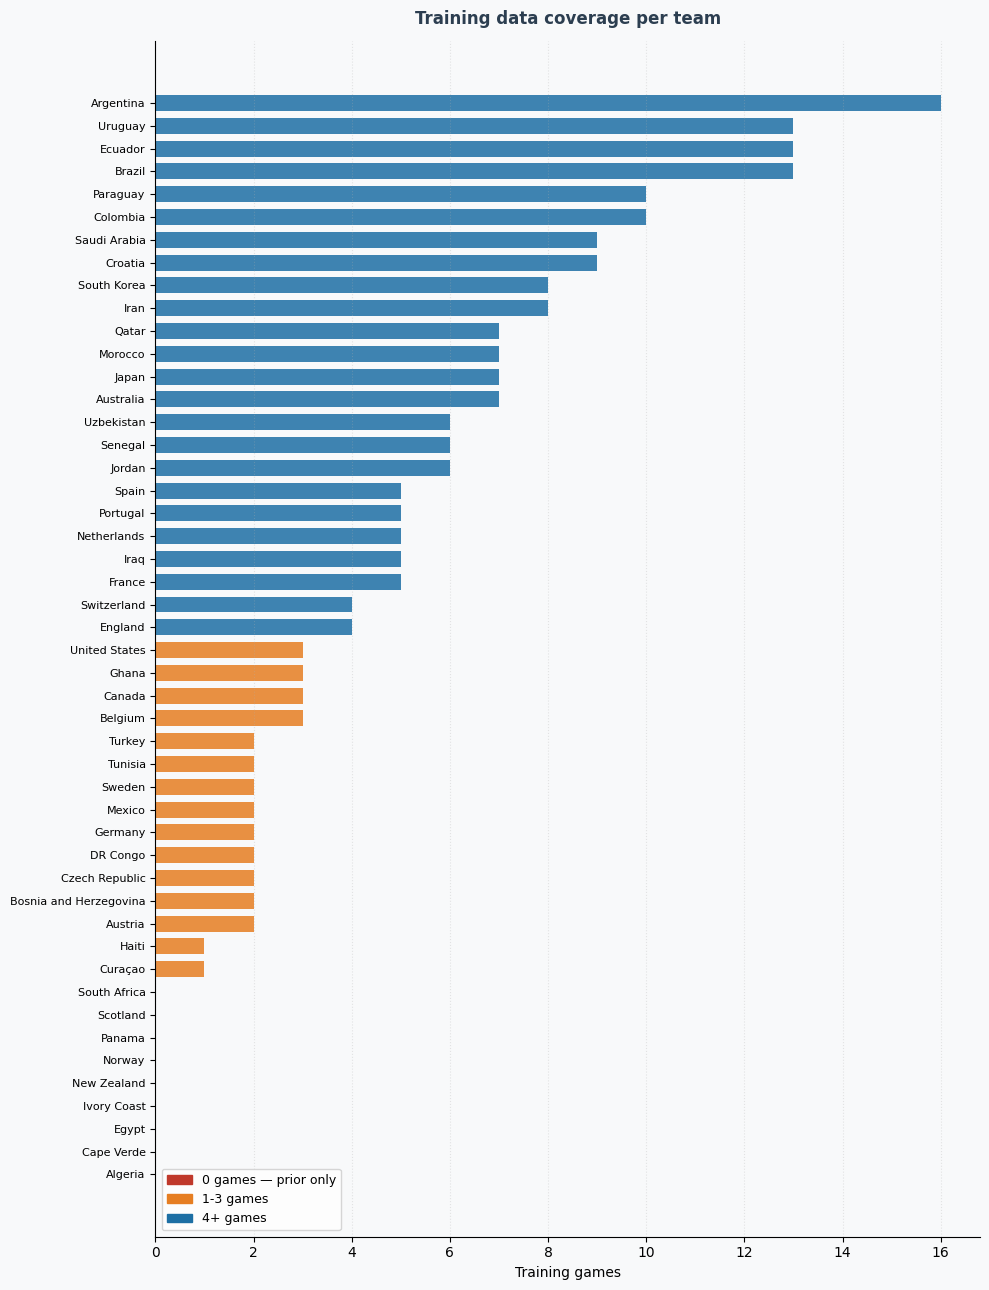

In [6]:
counts = {t: len(matches[(matches['home_team']==t)|(matches['away_team']==t)]) for t in teams}
sc = sorted(counts.items(), key=lambda x: x[1])
names, values = [x[0] for x in sc], [x[1] for x in sc]
colors_bar = [RED if v==0 else (GOLD if v<=3 else BLUE) for v in values]

fig, ax = plt.subplots(figsize=(10,13)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.barh(range(len(names)), values, color=colors_bar, alpha=0.85, height=0.7)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('Training games'); ax.spines[['top','right']].set_visible(False)
ax.set_title('Training data coverage per team', fontsize=12, fontweight='bold', color=DARK, pad=12)
ax.legend(handles=[mpatches.Patch(color=RED,label='0 games — prior only'),
                   mpatches.Patch(color=GOLD,label='1-3 games'),
                   mpatches.Patch(color=BLUE,label='4+ games')], fontsize=9)
ax.grid(axis='x', alpha=0.3, linestyle=':')
plt.tight_layout(); plt.show()

## 4. The statistical model

Score difference when favourite (team 1) plays underdog (team 2):

$$y_{ij} \sim t_7(a_i - a_j,\; \sigma_y)$$

Team ability prior informed by FIFA rankings:

$$a_i \sim \mathcal{N}(b \cdot s_i,\; \sigma_a)$$

Non-centred parameterisation for efficient sampling:

$$\tilde{a}_i \sim \mathcal{N}(0,1), \quad a_i = b \cdot s_i + \sigma_a \cdot \tilde{a}_i$$

In [7]:
def build_training(matches, team_idx, rankings):
    rows = []
    for _, row in matches.iterrows():
        h, a = row['home_team'], row['away_team']
        if rankings.get(h,999) <= rankings.get(a,999):
            fave, underdog, sd = h, a, float(row['home_score'])-float(row['away_score'])
        else:
            fave, underdog, sd = a, h, float(row['away_score'])-float(row['home_score'])
        if fave in team_idx and underdog in team_idx:
            rows.append({'team_1':fave,'team_2':underdog,
                         'team_1_idx':team_idx[fave],'team_2_idx':team_idx[underdog],'score_diff':sd})
    return pd.DataFrame(rows)

training = build_training(matches, team_idx, rankings)

stan_code = '''
data {
  int<lower=0> num_teams;
  int<lower=0> num_games;
  vector[num_teams] prior_score;
  array[num_games] int team_1_idx;
  array[num_games] int team_2_idx;
  vector[num_games] score_diff;
  real<lower=0> deg_freedom;
}
parameters {
  real b;
  real<lower=0> sigma_a;
  real<lower=0> sigma_y;
  vector[num_teams] raw_a;
}
transformed parameters {
  vector[num_teams] a;
  a = b * prior_score + sigma_a * raw_a;
}
model {
  raw_a ~ std_normal();
  for (i in 1:num_games)
    score_diff[i] ~ student_t(deg_freedom,
                              a[team_1_idx[i]] - a[team_2_idx[i]], sigma_y);
}
generated quantities {
  vector[num_games] ypred_train;
  for (i in 1:num_games)
    ypred_train[i] = student_t_rng(deg_freedom,
                                   a[team_1_idx[i]] - a[team_2_idx[i]], sigma_y);
}
'''

stan_data = {
    "num_teams":   len(teams),
    "num_games":   len(training),
    "prior_score": prior_score.tolist(),
    "team_1_idx":  training['team_1_idx'].astype(int).tolist(),
    "team_2_idx":  training['team_2_idx'].astype(int).tolist(),
    "score_diff":  training['score_diff'].astype(float).tolist(),
    "deg_freedom": 7.0,
}

print("Compiling Stan model...")
posterior = stan.build(stan_code, data=stan_data, random_seed=42)
print("Sampling (4 chains x 2000 draws)...")
fit = posterior.sample(num_chains=4, num_samples=2000, num_warmup=1000)
print("Done.")

a_samples = fit["a"]
sigma_y   = fit["sigma_y"]
b_samples = fit["b"]
a_means   = {t: a_samples[team_idx[t]-1].mean() for t in teams}
a_sds     = {t: a_samples[team_idx[t]-1].std()  for t in teams}
print(f"b mean={b_samples.mean():.3f},  sigma_y mean={sigma_y.mean():.3f}")

Compiling Stan model...
Building...

Building: found in cache, done.

Messages from stanc:


    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.


Sampling:   0%

...

  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:


  Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in '/var/folders/73/4qdxwp_54mb0mvs2p7s743pm0000gn/T/httpstan_n03e7j9r/model_m6wzsemx.stan', line 24, column 4 to line 25, column 76)


  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,


  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.


Done.
b mean=1.268,  sigma_y mean=1.330


## 5. Posterior diagnostics

### Figure 2 — Parameter posteriors

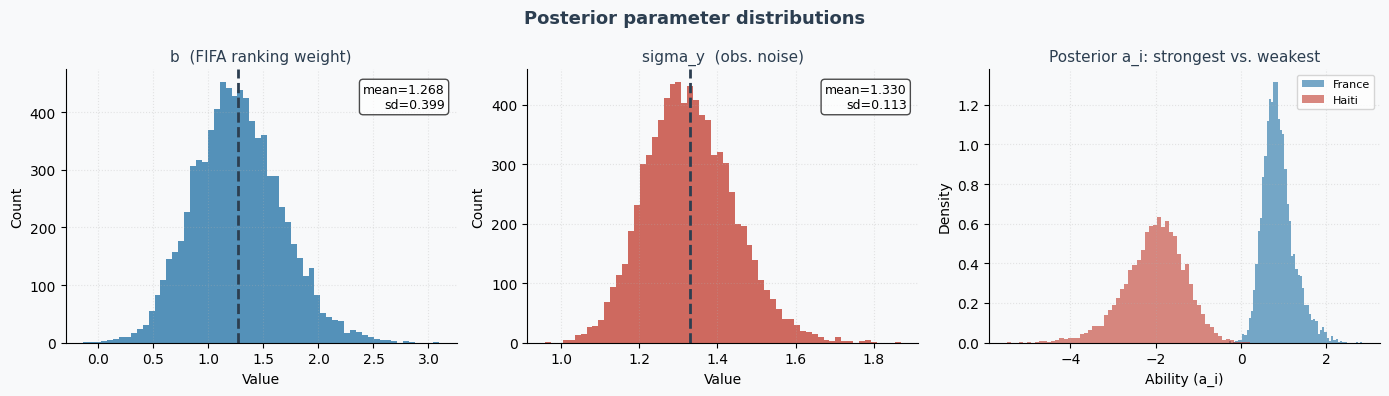

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14,4)); fig.patch.set_facecolor(BG)
fig.suptitle('Posterior parameter distributions', fontsize=13, fontweight='bold', color=DARK)

for ax, samp, label, col in [
    (axes[0], b_samples.flatten(),   'b  (FIFA ranking weight)',   BLUE),
    (axes[1], sigma_y.flatten(),     'sigma_y  (obs. noise)',      RED),
]:
    ax.set_facecolor(BG)
    ax.hist(samp, bins=60, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(samp.mean(), color=DARK, linewidth=2, linestyle='--')
    ax.set_title(label, fontsize=11, color=DARK)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.annotate(f"mean={samp.mean():.3f}\nsd={samp.std():.3f}",
                xy=(0.97,0.95), xycoords='axes fraction', ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.spines[['top','right']].set_visible(False); ax.grid(alpha=0.3, linestyle=':')

ax = axes[2]; ax.set_facecolor(BG)
top_t    = max(teams, key=lambda t: a_means[t])
bottom_t = min(teams, key=lambda t: a_means[t])
for t, col, lab in [(top_t,BLUE,top_t),(bottom_t,RED,bottom_t)]:
    ax.hist(a_samples[team_idx[t]-1], bins=60, color=col, alpha=0.6, label=lab, density=True)
ax.set_title('Posterior a_i: strongest vs. weakest', fontsize=11, color=DARK)
ax.set_xlabel('Ability (a_i)'); ax.set_ylabel('Density')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False); ax.grid(alpha=0.3,linestyle=':')
plt.tight_layout(); plt.show()

### Figure 1 — Team ability estimates

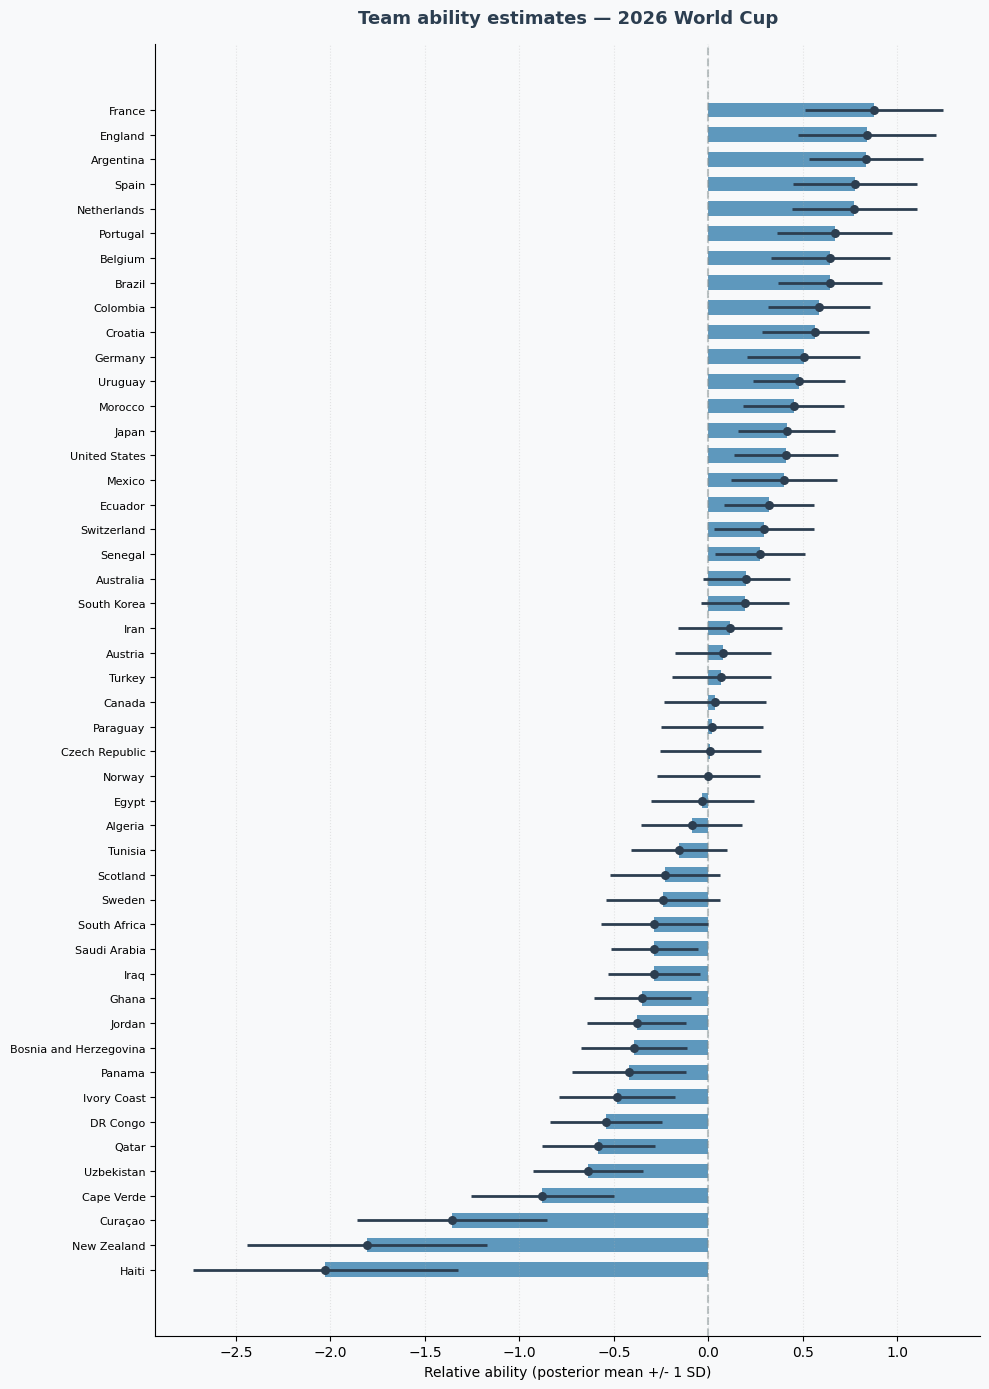

In [9]:
sorted_teams = sorted(teams, key=lambda t: a_means[t])
fig, ax = plt.subplots(figsize=(10,14)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
for i, t in enumerate(sorted_teams):
    mu, sd = a_means[t], a_sds[t]
    ax.barh(i, mu, color=BLUE, alpha=0.7, height=0.6)
    ax.hlines(i, mu-sd, mu+sd, color=DARK, linewidth=2, zorder=5)
    ax.scatter([mu],[i], color=DARK, s=30, zorder=6)
ax.axvline(0, color=GRAY, linestyle='--', alpha=0.5)
ax.set_yticks(range(len(sorted_teams))); ax.set_yticklabels(sorted_teams, fontsize=8)
ax.set_xlabel('Relative ability (posterior mean +/- 1 SD)')
ax.set_title('Team ability estimates — 2026 World Cup', fontsize=13, fontweight='bold', pad=15, color=DARK)
ax.spines[['top','right']].set_visible(False); ax.grid(axis='x', alpha=0.3, linestyle=':')
plt.tight_layout(); plt.show()

## 6. In-sample predictive check

### Figure 5

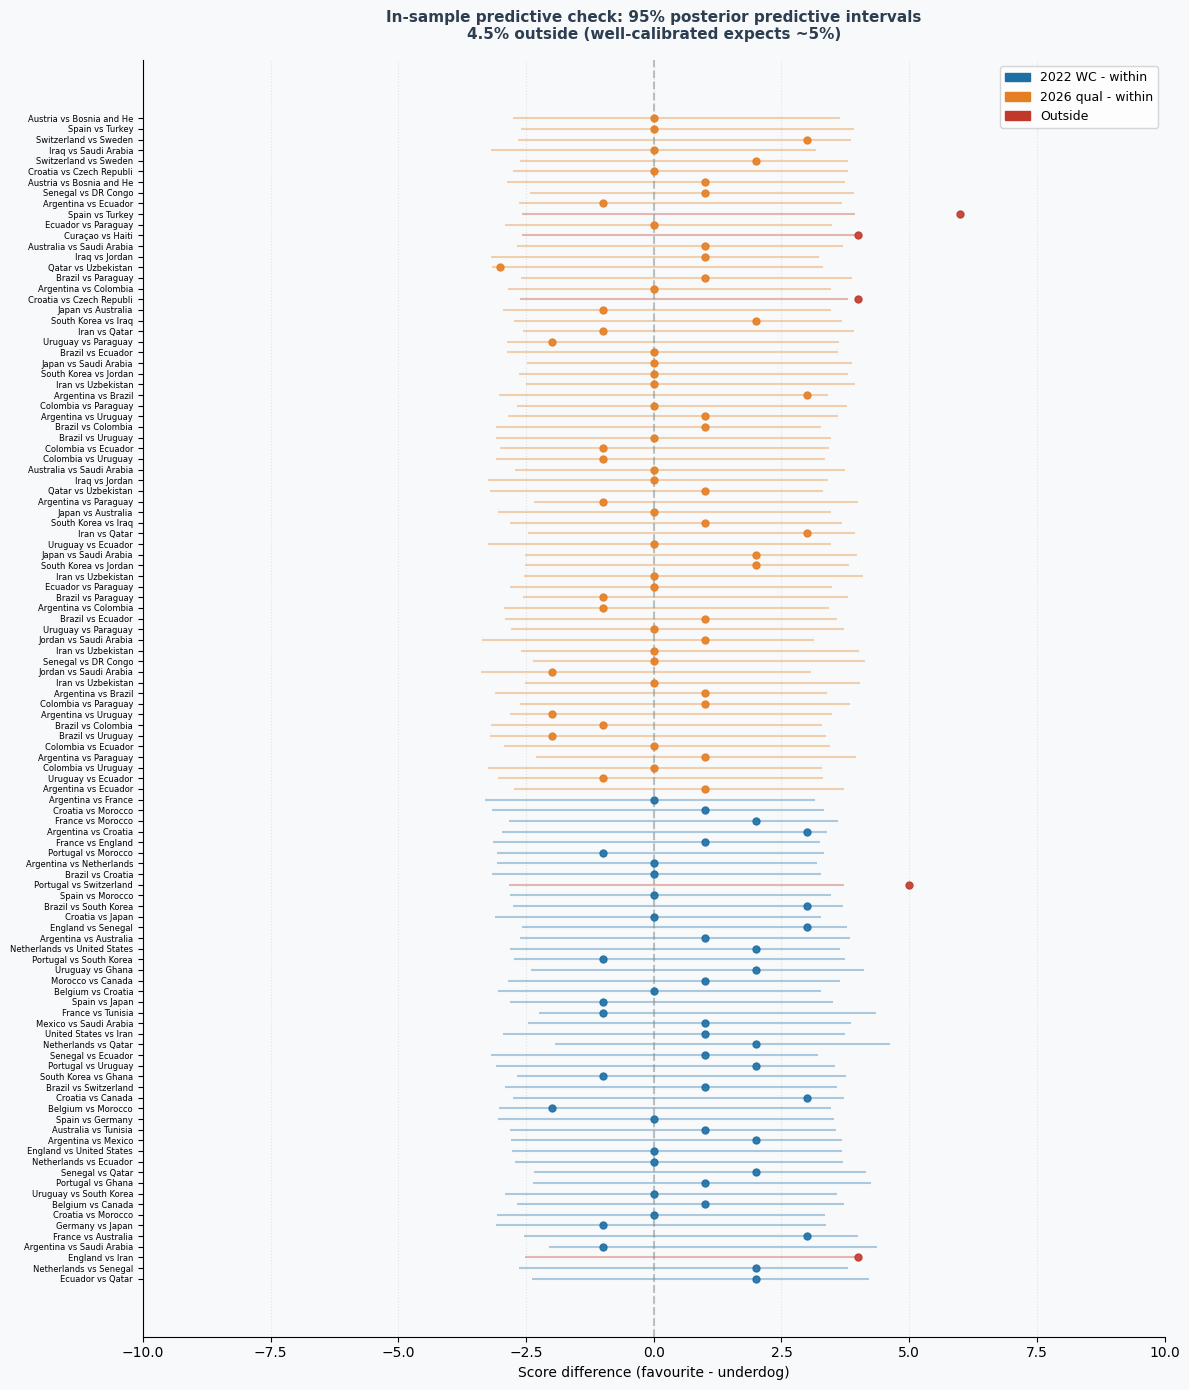

4.5% of training games outside the 95% interval.


In [10]:
q = 0.95
labels_list, actuals, lqs, uqs, srcs = [], [], [], [], []
for _, row in matches.iterrows():
    h, a = row['home_team'], row['away_team']
    hr, ar = rankings.get(h,999), rankings.get(a,999)
    if hr <= ar:
        fave, underdog, sd = h, a, float(row['home_score'])-float(row['away_score'])
    else:
        fave, underdog, sd = a, h, float(row['away_score'])-float(row['home_score'])
    if fave not in team_idx or underdog not in team_idx: continue
    fi, ui = team_idx[fave]-1, team_idx[underdog]-1
    diff   = a_samples[fi] - a_samples[ui]
    ypred  = t_dist.rvs(df=7, loc=diff, scale=sigma_y)
    lq, uq = np.quantile(ypred, [(1-q)/2, q+(1-q)/2])
    labels_list.append(f'{fave[:13]} vs {underdog[:13]}')
    actuals.append(sd); lqs.append(lq); uqs.append(uq); srcs.append(row['source'])

actuals = np.array(actuals)
outside = (actuals<np.array(lqs))|(actuals>np.array(uqs))
pct_out = outside.mean()*100

src_color = {'wc2022':BLUE,'qual2026':GOLD}
fig, ax = plt.subplots(figsize=(12,14)); fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
for i in range(len(labels_list)):
    col = RED if outside[i] else src_color.get(srcs[i],BLUE)
    ax.scatter(actuals[i], i, color=col, s=25, zorder=4, alpha=0.9)
    ax.hlines(i, lqs[i], uqs[i], color=col, alpha=0.35, linewidth=1.5)
ax.axvline(0, color=GRAY, linestyle='--', alpha=0.5); ax.set_xlim(-10,10)
ax.set_yticks(range(len(labels_list))); ax.set_yticklabels(labels_list, fontsize=6)
ax.set_xlabel('Score difference (favourite - underdog)')
ax.set_title(f'In-sample predictive check: {q*100:.0f}% posterior predictive intervals\n'
             f'{pct_out:.1f}% outside (well-calibrated expects ~{(1-q)*100:.0f}%)',
             fontsize=11, fontweight='bold', color=DARK, pad=15)
ax.spines[['top','right']].set_visible(False); ax.grid(axis='x', alpha=0.3, linestyle=':')
ax.legend(handles=[mpatches.Patch(color=BLUE,label='2022 WC - within'),
                   mpatches.Patch(color=GOLD,label='2026 qual - within'),
                   mpatches.Patch(color=RED, label='Outside')], fontsize=9)
plt.tight_layout(); plt.show()
print(f"{pct_out:.1f}% of training games outside the {q*100:.0f}% interval.")

## 7. Group stage predictions

### Figure 3 — All groups

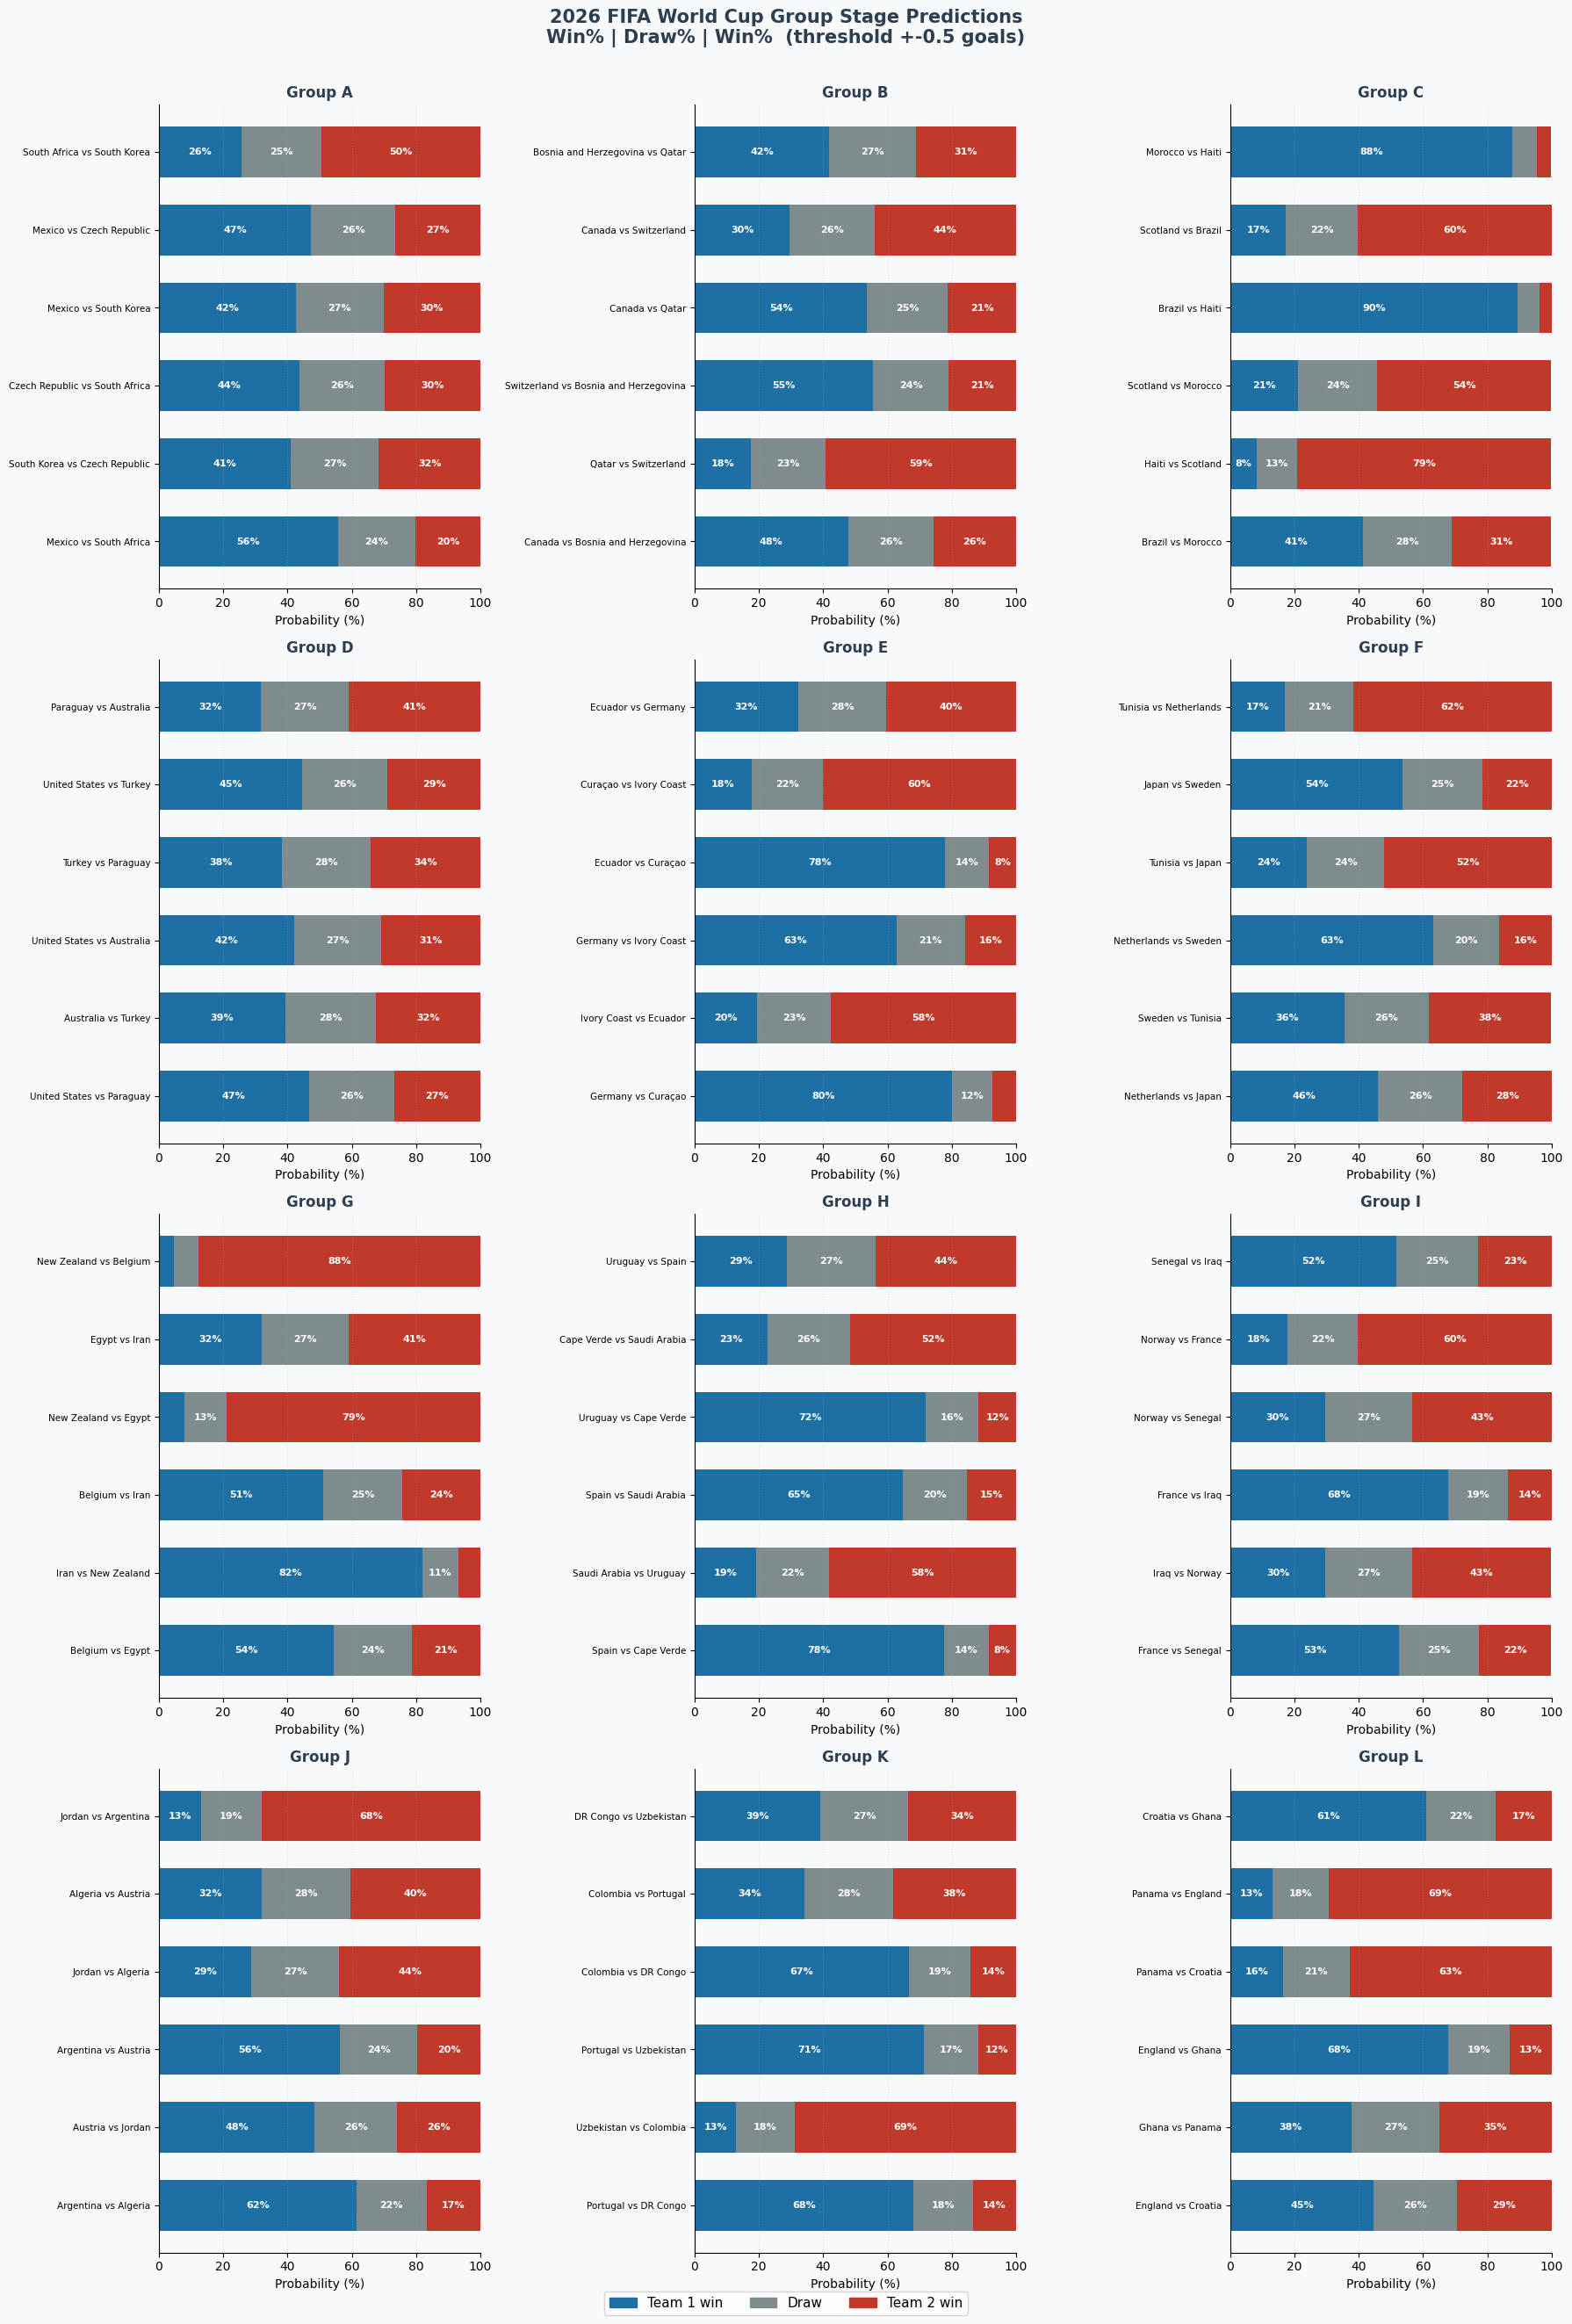

In [11]:
def predict_match(team1, team2):
    t1r, t2r = rankings.get(team1,999), rankings.get(team2,999)
    fave, underdog, fave_is_t1 = (team1,team2,True) if t1r<=t2r else (team2,team1,False)
    fi, ui = team_idx[fave]-1, team_idx[underdog]-1
    diff   = a_samples[fi] - a_samples[ui]
    ypred  = t_dist.rvs(df=7, loc=diff, scale=sigma_y)
    fw = np.mean(ypred> DRAW_THRESHOLD)
    d  = np.mean((ypred>=-DRAW_THRESHOLD)&(ypred<=DRAW_THRESHOLD))
    uw = np.mean(ypred<-DRAW_THRESHOLD)
    return (fw,d,uw) if fave_is_t1 else (uw,d,fw)

fixtures = df_all[
    (df_all['tournament']=='FIFA World Cup') &
    (df_all['date']>='2026-06-01') &
    (df_all['home_team'].isin(qualified_ds)) & (df_all['away_team'].isin(qualified_ds))
][['date','home_team','away_team']].copy()

rows = []
for _, row in fixtures.iterrows():
    t1, t2 = row['home_team'], row['away_team']
    w1, d, w2 = predict_match(t1, t2)
    rows.append({'group':team_group.get(t1,'?'),'date':row['date'],
                 'team1':t1,'team2':t2,
                 'team1_win':round(w1*100,1),'draw':round(d*100,1),'team2_win':round(w2*100,1)})
results = pd.DataFrame(rows).sort_values(['group','date'])

fig, axes = plt.subplots(4,3,figsize=(18,26)); fig.patch.set_facecolor(BG)
fig.suptitle('2026 FIFA World Cup Group Stage Predictions\nWin% | Draw% | Win%  (threshold +-0.5 goals)',
             fontsize=15, fontweight='bold', color=DARK, y=1.005)

for gi, grp in enumerate(sorted(groups.keys())):
    ax = axes[gi//3][gi%3]; ax.set_facecolor(BG)
    grp_df = results[results['group']==grp].reset_index(drop=True)
    for i, row in grp_df.iterrows():
        w1, d, w2 = row['team1_win'], row['draw'], row['team2_win']
        ax.barh(i, w1,          color=BLUE, height=0.65)
        ax.barh(i, d,   left=w1, color=GRAY, height=0.65)
        ax.barh(i, w2,  left=w1+d, color=RED, height=0.65)
        if w1>8:  ax.text(w1/2,     i,f'{w1:.0f}%',ha='center',va='center',fontsize=8,color='white',fontweight='bold')
        if d>8:   ax.text(w1+d/2,   i,f'{d:.0f}%', ha='center',va='center',fontsize=8,color='white',fontweight='bold')
        if w2>8:  ax.text(w1+d+w2/2,i,f'{w2:.0f}%',ha='center',va='center',fontsize=8,color='white',fontweight='bold')
    ax.set_yticks(range(len(grp_df)))
    ax.set_yticklabels([f"{r.team1} vs {r.team2}" for _,r in grp_df.iterrows()],fontsize=7.5)
    ax.set_xlim(0,100); ax.set_xlabel('Probability (%)'); ax.spines[['top','right']].set_visible(False)
    ax.set_title(f'Group {grp}',fontsize=12,fontweight='bold',color=DARK)
    ax.grid(axis='x',alpha=0.3,linestyle=':')

fig.legend(handles=[mpatches.Patch(color=BLUE,label='Team 1 win'),
                    mpatches.Patch(color=GRAY,label='Draw'),
                    mpatches.Patch(color=RED, label='Team 2 win')],
           loc='lower center',ncol=3,fontsize=11,bbox_to_anchor=(0.5,-0.008))
plt.tight_layout(); plt.show()

## 8. Caveats & known limitations

1. **Draw rates are approximated.** The ±0.5 threshold on a continuous distribution
   understates true draw frequency. A Dixon-Coles Poisson model would handle this better.

2. **9 teams have no match data.** Algeria, Cape Verde, Egypt, Ivory Coast, New Zealand,
   Norway, Panama, Scotland, South Africa — ability driven purely by FIFA ranking prior.

3. **FIFA rankings partially double-count qualifying data** (rankings are computed from
   recent results, some of which overlap with our training set).

4. **No home advantage.** Qualifying games are treated as neutral-venue.

5. **No temporal decay.** A 2023 qualifier counts equally to a 2025 one.

In [1]:
# --- All 72 group-stage games with official FIFA kickoff times (Eastern Time) ---
# Date / kickoff (ET) / venue are from the official 2026 FIFA World Cup match schedule
# (group pairings allocated after the 6 Dec 2025 final draw). Win/draw/win percentages
# keep the fixture's listed order (Team1 v Team2). Late kickoffs roll onto the next ET
# calendar day (e.g. a 9pm Pacific game in Vancouver is 12:00 AM ET the following day),
# which can differ from the source dataset's local match date.
# Times are matched to fixtures by team PAIR (order-independent), so the notebook's
# Team1/Team2 order and predictions are preserved even where FIFA lists home/away differently.
official_schedule = [   # (team1, team2, "YYYY-MM-DD HH:MM" ET, "venue, city")
    ("Mexico", "South Africa", "2026-06-11 15:00", "Estadio Azteca, Mexico City"),
    ("South Korea", "Czech Republic", "2026-06-11 22:00", "Estadio Akron, Zapopan"),
    ("Canada", "Bosnia and Herzegovina", "2026-06-12 15:00", "BMO Field, Toronto"),
    ("United States", "Paraguay", "2026-06-12 21:00", "SoFi Stadium, Inglewood"),
    ("Qatar", "Switzerland", "2026-06-13 15:00", "Levi's Stadium, Santa Clara"),
    ("Brazil", "Morocco", "2026-06-13 18:00", "MetLife Stadium, East Rutherford"),
    ("Haiti", "Scotland", "2026-06-13 21:00", "Gillette Stadium, Foxborough"),
    ("Australia", "Turkey", "2026-06-14 00:00", "BC Place, Vancouver"),
    ("Germany", "Curaçao", "2026-06-14 13:00", "NRG Stadium, Houston"),
    ("Netherlands", "Japan", "2026-06-14 16:00", "AT&T Stadium, Arlington"),
    ("Ivory Coast", "Ecuador", "2026-06-14 19:00", "Lincoln Financial Field, Philadelphia"),
    ("Sweden", "Tunisia", "2026-06-14 22:00", "Estadio BBVA, Monterrey"),
    ("Spain", "Cape Verde", "2026-06-15 12:00", "Mercedes-Benz Stadium, Atlanta"),
    ("Belgium", "Egypt", "2026-06-15 15:00", "Lumen Field, Seattle"),
    ("Saudi Arabia", "Uruguay", "2026-06-15 18:00", "Hard Rock Stadium, Miami Gardens"),
    ("Iran", "New Zealand", "2026-06-15 21:00", "SoFi Stadium, Inglewood"),
    ("France", "Senegal", "2026-06-16 15:00", "MetLife Stadium, East Rutherford"),
    ("Iraq", "Norway", "2026-06-16 18:00", "Gillette Stadium, Foxborough"),
    ("Argentina", "Algeria", "2026-06-16 21:00", "Arrowhead Stadium, Kansas City"),
    ("Austria", "Jordan", "2026-06-17 00:00", "Levi's Stadium, Santa Clara"),
    ("Portugal", "DR Congo", "2026-06-17 13:00", "NRG Stadium, Houston"),
    ("England", "Croatia", "2026-06-17 16:00", "AT&T Stadium, Arlington"),
    ("Ghana", "Panama", "2026-06-17 19:00", "BMO Field, Toronto"),
    ("Uzbekistan", "Colombia", "2026-06-17 22:00", "Estadio Azteca, Mexico City"),
    ("Czech Republic", "South Africa", "2026-06-18 12:00", "Mercedes-Benz Stadium, Atlanta"),
    ("Switzerland", "Bosnia and Herzegovina", "2026-06-18 15:00", "SoFi Stadium, Inglewood"),
    ("Canada", "Qatar", "2026-06-18 18:00", "BC Place, Vancouver"),
    ("Mexico", "South Korea", "2026-06-18 21:00", "Estadio Akron, Zapopan"),
    ("United States", "Australia", "2026-06-19 15:00", "Lumen Field, Seattle"),
    ("Scotland", "Morocco", "2026-06-19 18:00", "Gillette Stadium, Foxborough"),
    ("Brazil", "Haiti", "2026-06-19 20:30", "Lincoln Financial Field, Philadelphia"),
    ("Turkey", "Paraguay", "2026-06-19 23:00", "Levi's Stadium, Santa Clara"),
    ("Netherlands", "Sweden", "2026-06-20 13:00", "NRG Stadium, Houston"),
    ("Germany", "Ivory Coast", "2026-06-20 16:00", "BMO Field, Toronto"),
    ("Ecuador", "Curaçao", "2026-06-20 20:00", "Arrowhead Stadium, Kansas City"),
    ("Tunisia", "Japan", "2026-06-21 00:00", "Estadio BBVA, Monterrey"),
    ("Spain", "Saudi Arabia", "2026-06-21 12:00", "Mercedes-Benz Stadium, Atlanta"),
    ("Belgium", "Iran", "2026-06-21 15:00", "SoFi Stadium, Inglewood"),
    ("Uruguay", "Cape Verde", "2026-06-21 18:00", "Hard Rock Stadium, Miami Gardens"),
    ("New Zealand", "Egypt", "2026-06-21 21:00", "BC Place, Vancouver"),
    ("Argentina", "Austria", "2026-06-22 13:00", "AT&T Stadium, Arlington"),
    ("France", "Iraq", "2026-06-22 17:00", "Lincoln Financial Field, Philadelphia"),
    ("Norway", "Senegal", "2026-06-22 20:00", "MetLife Stadium, East Rutherford"),
    ("Jordan", "Algeria", "2026-06-22 23:00", "Levi's Stadium, Santa Clara"),
    ("Portugal", "Uzbekistan", "2026-06-23 13:00", "NRG Stadium, Houston"),
    ("England", "Ghana", "2026-06-23 16:00", "Gillette Stadium, Foxborough"),
    ("Panama", "Croatia", "2026-06-23 19:00", "BMO Field, Toronto"),
    ("Colombia", "DR Congo", "2026-06-23 22:00", "Estadio Akron, Zapopan"),
    ("Switzerland", "Canada", "2026-06-24 15:00", "BC Place, Vancouver"),
    ("Bosnia and Herzegovina", "Qatar", "2026-06-24 15:00", "Lumen Field, Seattle"),
    ("Scotland", "Brazil", "2026-06-24 18:00", "Hard Rock Stadium, Miami Gardens"),
    ("Morocco", "Haiti", "2026-06-24 18:00", "Mercedes-Benz Stadium, Atlanta"),
    ("Czech Republic", "Mexico", "2026-06-24 21:00", "Estadio Azteca, Mexico City"),
    ("South Africa", "South Korea", "2026-06-24 21:00", "Estadio BBVA, Monterrey"),
    ("Curaçao", "Ivory Coast", "2026-06-25 16:00", "Lincoln Financial Field, Philadelphia"),
    ("Ecuador", "Germany", "2026-06-25 16:00", "MetLife Stadium, East Rutherford"),
    ("Japan", "Sweden", "2026-06-25 19:00", "AT&T Stadium, Arlington"),
    ("Tunisia", "Netherlands", "2026-06-25 19:00", "Arrowhead Stadium, Kansas City"),
    ("Turkey", "United States", "2026-06-25 22:00", "SoFi Stadium, Inglewood"),
    ("Paraguay", "Australia", "2026-06-25 22:00", "Levi's Stadium, Santa Clara"),
    ("Norway", "France", "2026-06-26 15:00", "Gillette Stadium, Foxborough"),
    ("Senegal", "Iraq", "2026-06-26 15:00", "BMO Field, Toronto"),
    ("Cape Verde", "Saudi Arabia", "2026-06-26 20:00", "NRG Stadium, Houston"),
    ("Uruguay", "Spain", "2026-06-26 20:00", "Estadio Akron, Zapopan"),
    ("Egypt", "Iran", "2026-06-26 23:00", "Lumen Field, Seattle"),
    ("New Zealand", "Belgium", "2026-06-26 23:00", "BC Place, Vancouver"),
    ("Panama", "England", "2026-06-27 17:00", "MetLife Stadium, East Rutherford"),
    ("Croatia", "Ghana", "2026-06-27 17:00", "Lincoln Financial Field, Philadelphia"),
    ("Colombia", "Portugal", "2026-06-27 19:30", "Hard Rock Stadium, Miami Gardens"),
    ("DR Congo", "Uzbekistan", "2026-06-27 19:30", "Mercedes-Benz Stadium, Atlanta"),
    ("Algeria", "Austria", "2026-06-27 22:00", "Arrowhead Stadium, Kansas City"),
    ("Jordan", "Argentina", "2026-06-27 22:00", "AT&T Stadium, Arlington"),
]

# Look up by unordered team pair so home/away differences vs FIFA don't cause misses
kickoff = {frozenset((a, b)): (ts, venue) for a, b, ts, venue in official_schedule}
assert len(kickoff) == len(official_schedule) == 72, "Expected 72 unique fixtures"

sched = results.copy()
keys  = [frozenset((r.team1, r.team2)) for r in sched.itertuples()]
missing = sorted(tuple(k) for k in keys if k not in kickoff)
assert not missing, f"No official kickoff found for: {missing}"

sched['kickoff_et'] = pd.to_datetime([kickoff[k][0] for k in keys])
sched['venue']      = [kickoff[k][1] for k in keys]
sched = sched.sort_values(['kickoff_et', 'group']).reset_index(drop=True)

fixtures_table = pd.DataFrame({
    'Date':         sched['kickoff_et'].dt.strftime('%a %b %d'),
    'Kickoff (ET)': sched['kickoff_et'].dt.strftime('%I:%M %p').str.lstrip('0'),
    'Grp':          sched['group'],
    'Match (Team1 v Team2)': sched['team1'] + '  v  ' + sched['team2'],
    'Team1 win %':  sched['team1_win'],
    'Draw %':       sched['draw'],
    'Team2 win %':  sched['team2_win'],
    'Venue':        sched['venue'],
})
fixtures_table.index = range(1, len(fixtures_table) + 1)
fixtures_table.index.name = 'Game'

print(f"{len(fixtures_table)} group-stage fixtures in official kickoff order (Eastern Time):\n")
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None, 'display.width', 200):
    display(fixtures_table)

NameError: name 'results' is not defined